<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>INTELIGÊNCIA ARTIFICIAL - Trabalho 3</center></h1>

- Nome completo: <João Pedro Jendiroba Paixão Corrêa>
- [Link para vídeo](<https://youtu.be/hPZiCM5I0o4>)

## 2. Redes Neurais MLP com PyTorch (2 pts)

### 2.2 Parte B – Regressão

#### 2.2.1 EDA

Amostras iniciais:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      

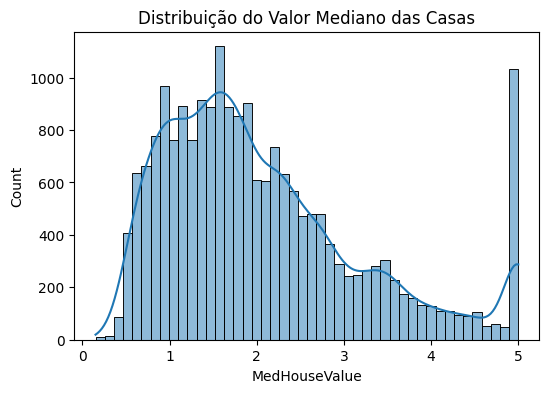

In [4]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target
print("Amostras iniciais:")
print(X.head())
print(X.describe())

# Distribuição do target
plt.figure(figsize=(6, 4))
sns.histplot(y, kde=True)
plt.title("Distribuição do Valor Mediano das Casas")
plt.xlabel("MedHouseValue")
plt.show()


#### 2.2.2 Pré Processamento

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Divisão inicial em treino+validação e teste
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42) # Divisão do treino+validação em treino e validação

scaler = StandardScaler() # Padronização para igualar as escalas
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
# Exibição das dimensões e primeiras linhas
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("Primeiras linhas de X_train:\n", X_train[:5])
print("Primeiros valores de y_train:", y_train[:10])

X_train shape: (12384, 8)
X_val shape: (4128, 8)
X_test shape: (4128, 8)
Primeiras linhas de X_train:
 [[-0.79547754  0.8260251  -0.71694298 -0.20409736 -0.02041282  0.10188491
  -0.56877746 -0.04497204]
 [ 3.31836617 -0.36373696  1.03623684 -0.29694588  0.7193329  -0.03451767
  -0.89258573  0.628346  ]
 [-1.16419606  0.98466004 -0.72389784 -0.4853724  -0.50072165 -0.06971956
   1.63687302 -1.01754255]
 [ 0.51013134 -1.55349902 -0.10144629 -0.22863372  0.40029565 -0.13771992
  -0.65794206  0.47373223]
 [ 0.91099754  0.74670763  0.76936986 -0.3117686  -0.37976796 -0.07305618
   0.8813204  -1.35669534]]
Primeiros valores de y_train: [2.414   5.00001 0.641   2.772   4.17    5.00001 3.677   5.00001 3.762
 0.535  ]


#### 2.2.3 Conversão para tensor 

In [6]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

#### 2.2.4 Definição de modelo MLP pra regressão

In [9]:
import torch.nn as nn
import torch.optim as optim

class MLPRegressor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLPRegressor(X.shape[1])
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

#### 2.2.5 Treinamento

In [10]:
# Definição de uma rede neural simples (MLP) com uma camada oculta
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    pred = model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t)
        val_losses.append(val_loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

#### 2.2.6 Avaliação

In [15]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_t)
    rmse = mean_squared_error(y_test, y_pred_test.numpy())
    print(f"RMSE no conjunto de teste: {rmse:.4f}")

RMSE no conjunto de teste: 0.3772


#### 2.2.7 Curva de perda

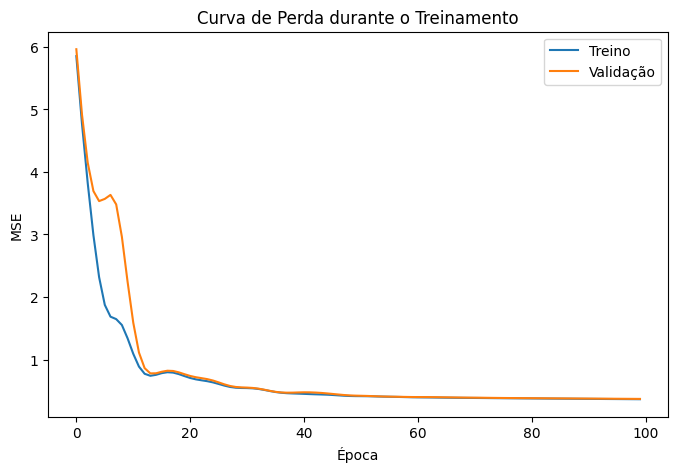

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.title("Curva de Perda durante o Treinamento")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.show()